In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"E:\Datasets\Hospital ER.csv")

# Inspect dataset

In [3]:
df.shape

(9216, 11)

In [4]:
df.columns

Index(['date', 'patient_id', 'patient_gender', 'patient_age',
       'patient_sat_score', 'patient_first_inital', 'patient_last_name',
       'patient_race', 'patient_admin_flag', 'patient_waittime',
       'department_referral'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9216 entries, 0 to 9215
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  9216 non-null   object 
 1   patient_id            9216 non-null   object 
 2   patient_gender        9216 non-null   object 
 3   patient_age           9216 non-null   int64  
 4   patient_sat_score     2517 non-null   float64
 5   patient_first_inital  9216 non-null   object 
 6   patient_last_name     9216 non-null   object 
 7   patient_race          9216 non-null   object 
 8   patient_admin_flag    9216 non-null   bool   
 9   patient_waittime      9216 non-null   int64  
 10  department_referral   3816 non-null   object 
dtypes: bool(1), float64(1), int64(2), object(7)
memory usage: 729.1+ KB


# Data cleaning

 ## convert Date column data type to datetime

In [6]:
df["date"]=pd.to_datetime(df["date"])

## Exrtract month and year from date column

In [7]:
from datetime import date as dt
df["month_year"]=df["date"].dt.strftime("%B %Y")

In [8]:
df[["date","month_year"]]


,date,month_year
0,2020-03-20 08:47:01,March 2020
1,2020-06-15 11:29:36,June 2020
2,2020-06-20 09:13:13,June 2020
3,2020-02-04 22:34:29,February 2020
4,2020-09-04 17:48:27,September 2020
...,...,...
9211,2020-10-25 02:35:03,October 2020
9212,2019-09-29 15:50:17,September 2019
9213,2020-08-12 14:46:37,August 2020
9214,2019-10-11 16:46:15,October 2019


In [9]:
## I need convert month_year data type fro,m  string to date
df["month_year"]=pd.to_datetime(df["month_year"],format="%B %Y")

In [10]:
df["month_year"].dtype

dtype('<M8[ns]')

In [11]:
df["month_year"]

0      2020-03-01
1      2020-06-01
2      2020-06-01
3      2020-02-01
4      2020-09-01
          ...    
9211   2020-10-01
9212   2019-09-01
9213   2020-08-01
9214   2019-10-01
9215   2019-06-01
Name: month_year, Length: 9216, dtype: datetime64[ns]

## Categories Age intoGroups

In [12]:
age_categories=["0-18years","19-65years","65years+"]
ranges=[0,18,65,np.inf]
df["Age_groups"]=pd.cut(df["patient_age"],bins=ranges,labels=age_categories)

In [13]:
df[["patient_age","Age_groups"]]

,patient_age,Age_groups
0,69,65years+
1,4,0-18years
2,56,19-65years
3,24,19-65years
4,5,0-18years
...,...,...
9211,60,19-65years
9212,63,19-65years
9213,27,19-65years
9214,53,19-65years


# check dupplicate values

In [14]:
df.duplicated().sum()

0

# Check if there any missing values

In [15]:
df.isna().sum()

date                       0
patient_id                 0
patient_gender             0
patient_age                0
patient_sat_score       6699
patient_first_inital       0
patient_last_name          0
patient_race               0
patient_admin_flag         0
patient_waittime           0
department_referral     5400
month_year                 0
Age_groups                 0
dtype: int64

# Check for inconsitencies

In [16]:
for x in df.columns:
    print(df[x].unique)

<bound method Series.unique of 0      2020-03-20 08:47:01
1      2020-06-15 11:29:36
2      2020-06-20 09:13:13
3      2020-02-04 22:34:29
4      2020-09-04 17:48:27
               ...        
9211   2020-10-25 02:35:03
9212   2019-09-29 15:50:17
9213   2020-08-12 14:46:37
9214   2019-10-11 16:46:15
9215   2019-06-01 07:48:20
Name: date, Length: 9216, dtype: datetime64[ns]>
<bound method Series.unique of 0       145-39-5406
1       316-34-3057
2       897-46-3852
3       358-31-9711
4       289-26-0537
           ...     
9211    453-45-2632
9212    136-93-5822
9213    822-41-7734
9214    260-14-4032
9215    703-55-3364
Name: patient_id, Length: 9216, dtype: object>
<bound method Series.unique of 0       M
1       M
2       F
3       F
4       M
       ..
9211    M
9212    M
9213    F
9214    M
9215    M
Name: patient_gender, Length: 9216, dtype: object>
<bound method Series.unique of 0       69
1        4
2       56
3       24
4        5
        ..
9211    60
9212    63
9213    27
921

# Exploratry Data Analaysis (EDA)

### statistical view of categorcal columns

In [17]:
df.select_dtypes(include=object).describe()

,patient_id,patient_gender,patient_first_inital,patient_last_name,patient_race,department_referral
count,9216,9216,9216,9216,9216,3816
unique,9216,3,26,8400,7,7
top,145-39-5406,M,C,Haslum,White,General Practice
freq,1,4705,383,4,2571,1840


In [24]:
df.columns = df.columns.str.strip()


<Axes: xlabel='patient_race', ylabel='count'>

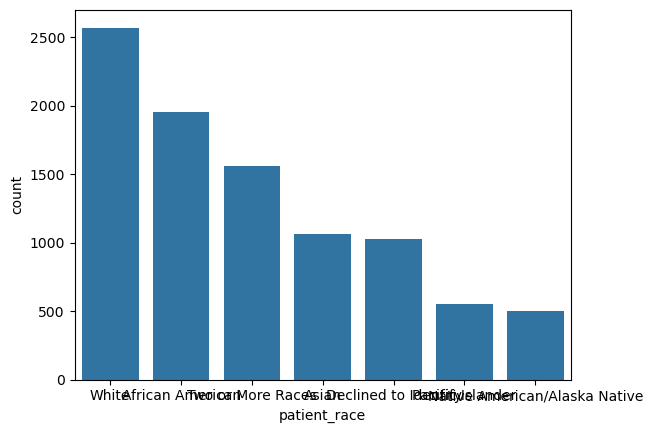

In [29]:
race_counts = df["patient_race"].value_counts().reset_index()
race_counts.columns = ["patient_race", "count"]

sns.barplot(x="patient_race", y="count", data=race_counts)
